In [1]:

# Setup Spark Session
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.config.engine_session import get_spark_session
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

spark = get_spark_session("GoldEnglandEDA")
df = spark.read.parquet("s3a://gold/england_water_quality")
    

In [2]:

# 1. Data Overview
print(f"Total baris observasi: {df.count():,}")
print("\n--- Schema ---")
df.printSchema()
print("\n--- Sampel Data ---")
df.show(5, truncate=False)
    

Total baris observasi: 449

--- Schema ---
root
 |-- Country: string (nullable = true)
 |-- Area: string (nullable = true)
 |-- Waterbody_Type: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Ammonia_mg_l: float (nullable = true)
 |-- Biochemical_Oxygen_Demand_mg_l: float (nullable = true)
 |-- Dissolved_Oxygen_mg_l: float (nullable = true)
 |-- Orthophosphate_mg_l: float (nullable = true)
 |-- pH_ph_units: float (nullable = true)
 |-- Temperature_cel: float (nullable = true)
 |-- Nitrogen_mg_l: float (nullable = true)
 |-- Nitrate_mg_l: float (nullable = true)
 |-- CCME_Values: float (nullable = true)
 |-- CCME_WQI: string (nullable = true)
 |-- population_density: float (nullable = true)
 |-- station_id: string (nullable = true)
 |-- year: integer (nullable = true)


--- Sampel Data ---
+-------+---------------------------+--------------+----------+------------+------------------------------+---------------------+-------------------+-----------+---------------+-----

In [3]:

# 2. Data Quality Assessment (Missing Values & Duplicates)
print("--- Missing Values Check ---")
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()

print("--- Duplicate Check ---")
print(f"Jumlah baris duplikat (exact match): {df.count() - df.dropDuplicates().count()}")
    

--- Missing Values Check ---
+-------+----+--------------+----+------------+------------------------------+---------------------+-------------------+-----------+---------------+-------------+------------+-----------+--------+------------------+----------+----+
|Country|Area|Waterbody_Type|Date|Ammonia_mg_l|Biochemical_Oxygen_Demand_mg_l|Dissolved_Oxygen_mg_l|Orthophosphate_mg_l|pH_ph_units|Temperature_cel|Nitrogen_mg_l|Nitrate_mg_l|CCME_Values|CCME_WQI|population_density|station_id|year|
+-------+----+--------------+----+------------+------------------------------+---------------------+-------------------+-----------+---------------+-------------+------------+-----------+--------+------------------+----------+----+
|      0|   0|             0|   0|           0|                             0|                    0|                  0|          0|              0|            0|           0|          0|       0|                 0|         0|   0|
+-------+----+--------------+----+---------

In [4]:

# 3. Anomaly & String Cleansing (Khusus Data Kotor/Tersensor)
# Di Gold Layer, data sudah berbentuk float (hasil Silver cleansing), 
# namun kita validasi apakah ada nilai non-numerik tersisa jika CCME_WQI aneh.
print("Check anomali tipe WQI:")
df.groupBy("CCME_WQI").count().show()
    

Check anomali tipe WQI:
+---------+-----+
| CCME_WQI|count|
+---------+-----+
|     Fair|   67|
|Excellent|   69|
|     Good|  181|
|     Poor|   25|
| Marginal|  107|
+---------+-----+



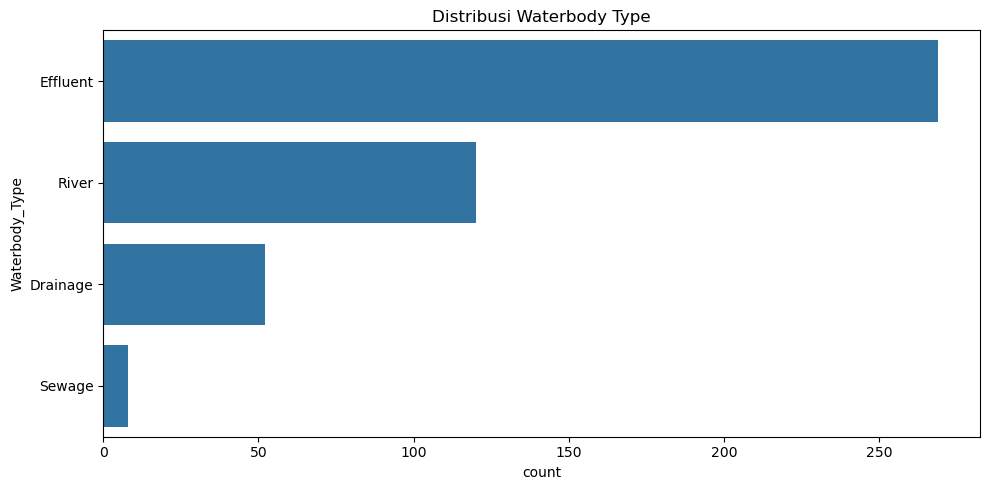

In [5]:

# 4. Categorical Analysis
top_cats = df.groupBy("Waterbody_Type").count().orderBy(F.desc("count")).limit(10).toPandas()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_cats, x="count", y="Waterbody_Type")
plt.title("Distribusi Waterbody Type")
plt.tight_layout()
plt.show()
    

In [6]:

# 5. Descriptive Statistic
# Select numeric columns
num_cols = ["Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l", 
            "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel", "Nitrogen_mg_l", 
            "Nitrate_mg_l", "population_density"]
df.select(num_cols).summary("count", "mean", "min", "max", "stddev").show()
    

+-------+------------------+------------------------------+---------------------+-------------------+------------------+------------------+-----------------+-----------------+------------------+
|summary|      Ammonia_mg_l|Biochemical_Oxygen_Demand_mg_l|Dissolved_Oxygen_mg_l|Orthophosphate_mg_l|       pH_ph_units|   Temperature_cel|    Nitrogen_mg_l|     Nitrate_mg_l|population_density|
+-------+------------------+------------------------------+---------------------+-------------------+------------------+------------------+-----------------+-----------------+------------------+
|  count|               449|                           449|                  449|                449|               449|               449|              449|              449|               449|
|   mean|1.3942179538782495|             5.431559046021017|   10.241719943643412| 1.3436837417440683|  7.73040095734968|11.314654820214932|6.961570259722941|6.429224941605715| 806.4155239241161|
|    min|              0.

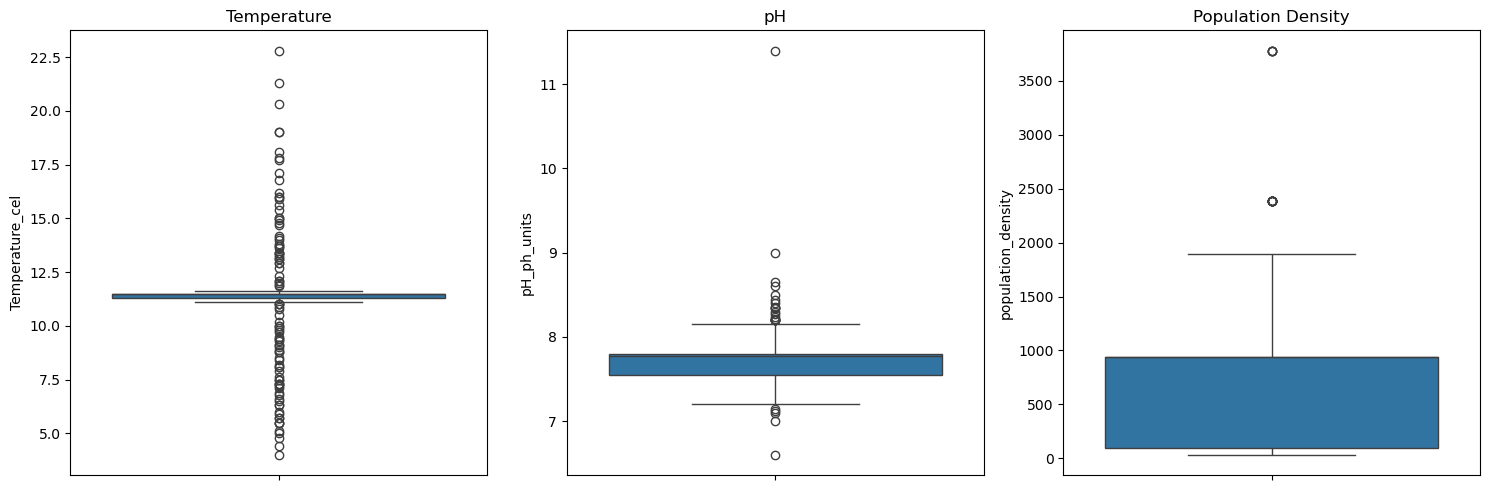

In [7]:

# 6. Distribution Analysis / Outlier Detection
sample_pd = df.select("Temperature_cel", "pH_ph_units", "population_density").sample(fraction=0.5).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=sample_pd, y="Temperature_cel", ax=axes[0]).set_title("Temperature")
sns.boxplot(data=sample_pd, y="pH_ph_units", ax=axes[1]).set_title("pH")
sns.boxplot(data=sample_pd, y="population_density", ax=axes[2]).set_title("Population Density")
plt.tight_layout()
plt.show()
    

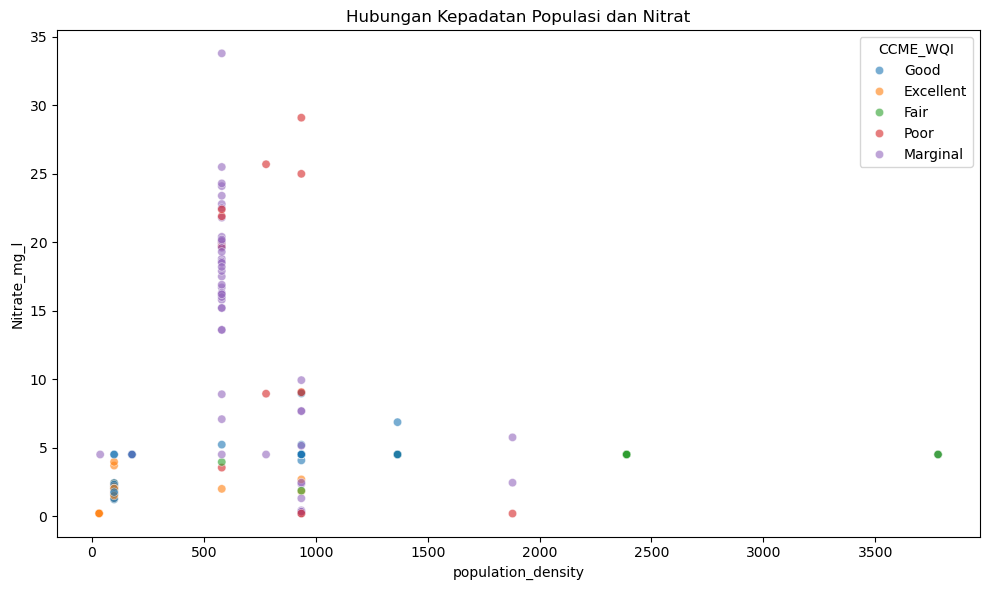

In [8]:

# 7. Relationship / Spatial Analysis
# Hubungan kepadatan populasi dengan Nitrate
sample_pd = df.select("population_density", "Nitrate_mg_l", "CCME_WQI").sample(fraction=0.5).toPandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_pd, x="population_density", y="Nitrate_mg_l", hue="CCME_WQI", alpha=0.6)
plt.title("Hubungan Kepadatan Populasi dan Nitrat")
plt.tight_layout()
plt.show()
    

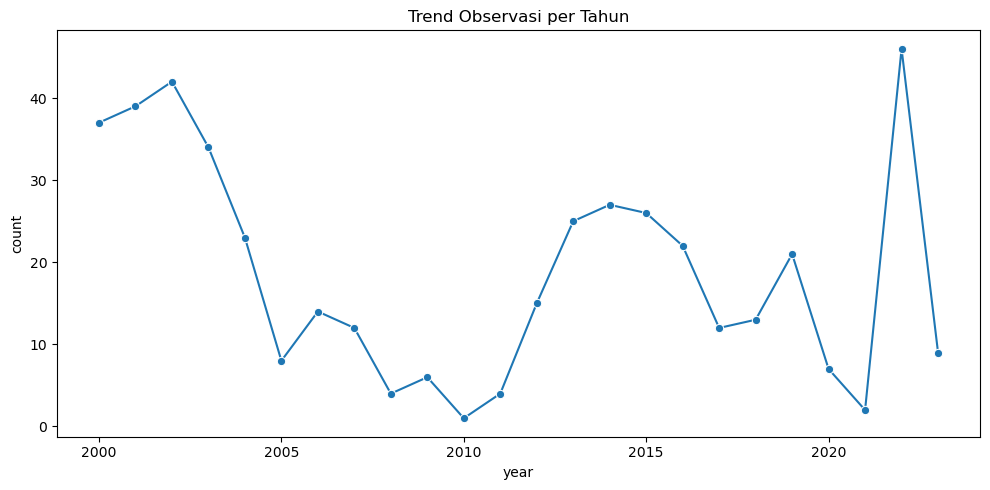

In [9]:

# 8. Time-Based Analysis
monthly_counts = df.groupBy("year").count().orderBy("year").toPandas()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_counts, x="year", y="count", marker="o")
plt.title("Trend Observasi per Tahun")
plt.tight_layout()
plt.show()
    

In [10]:

# 9. Data Consistency Check
invalid_dates = df.filter(F.col("year") > 2026).count()
print(f"Baris dengan tahun di masa depan: {invalid_dates}")
    

Baris dengan tahun di masa depan: 0


In [11]:

# 10. Business/Domain Validation
invalid_temp = df.filter((F.col("Temperature_cel") < -10) | (F.col("Temperature_cel") > 60))
print(f"Anomali suhu ekstrem (di luar -10 s/d 60): {invalid_temp.count():,} baris")

poor_wqi = df.filter(F.col("CCME_WQI") == "Poor").count()
print(f"Total observasi WQI 'Poor': {poor_wqi:,} baris")
    

Anomali suhu ekstrem (di luar -10 s/d 60): 0 baris
Total observasi WQI 'Poor': 25 baris
